## 📊 Mini-reto 12 | Visualización Exploratoria de Datos Energéticos en Zonas No Interconectadas

## 🧩 Contexto del Problema

Después de limpiar, enriquecer y reorganizar los datos energéticos de las **Zonas No Interconectadas**, el siguiente paso consiste en construir visualizaciones que permitan interpretar el comportamiento territorial y temporal de la prestación del servicio de energía.

En este mini-reto trabajarás con el DataFrame `df_zni`, previamente depurado y enriquecido con los nombres oficiales de departamentos, municipios y localidades. A partir de esta base, deberás construir diferentes gráficos que permitan responder preguntas como:

- ¿Qué departamentos concentran mayor energía activa?
- ¿Cuáles son los municipios con mayores valores registrados?
- ¿Cómo se comparan la energía activa y la energía reactiva por departamento?
- ¿Cómo ha evolucionado la energía activa a través de los años?

La visualización de datos permite transformar tablas extensas en representaciones gráficas que facilitan la comparación, la identificación de patrones y la comunicación de resultados para la toma de decisiones en análisis energético territorial.



### 🎯 Objetivos

- Agrupar los datos por departamento, municipio y año de servicio.
- Construir visualizaciones para comparar energía activa y energía reactiva.
- Identificar territorios con mayores valores registrados.
- Analizar la evolución anual de la energía activa.
- Revisar si existen diferencias de escala que requieran filtrar los datos.
- Interpretar los patrones observados en las gráficas.



### 📋 Criterios de Calidad

>✅ Datos agrupados correctamente.
>
>✅ Gráficos claros y legibles.
>
>✅ Escalas revisadas.
>
>✅ Filtros justificados.
>
>✅ Interpretaciones coherentes.



### 🧪 Desarrollo del Mini-reto

#### 1. Preparar los datos agrupados

Antes de graficar, es necesario crear tablas resumidas. Estas tablas permiten pasar de registros individuales a valores agregados por territorio o por año.

```python
import matplotlib.pyplot as plt

# 'Agrupar energía activa y reactiva por departamento'
df_departamento = df_zni.groupby('DEPARTAMENTO')[['ENERGÍA ACTIVA', 'ENERGÍA REACTIVA']].sum().reset_index()

# 'Agrupar energía activa y reactiva por departamento y municipio'
df_municipio = df_zni.groupby(['DEPARTAMENTO', 'MUNICIPIO'])[['ENERGÍA ACTIVA', 'ENERGÍA REACTIVA']].sum().reset_index()

# 'Agrupar energía activa y reactiva por año de servicio'
df_anual = df_zni.groupby('AÑO SERVICIO')[['ENERGÍA ACTIVA', 'ENERGÍA REACTIVA']].sum().reset_index()
```

### 🔎 Consideración metodológica sobre órdenes de magnitud

Antes de construir las visualizaciones, revisa si los valores de energía activa, energía reactiva o potencia máxima presentan diferencias muy marcadas entre territorios.

Cuando existen valores con órdenes de magnitud muy distintos, una gráfica puede quedar dominada por pocos registros y dificultar la interpretación del resto de los datos. Por esta razón, como analista debes decidir si conviene:

- conservar todos los registros;
- filtrar registros atípicos o no comparables;
- analizar por separado territorios con comportamientos muy diferentes;
- trabajar solo con territorios de la Colombia continental para mantener una comparación territorial más homogénea.

En este mini-reto, si las diferencias de escala afectan la lectura de los gráficos, se recomienda construir una versión filtrada del DataFrame antes de graficar.


In [18]:
import pandas as pd

ruta_zni = 'https://github.com/juliandariogiraldoocampo/analisis_taltech/raw/refs/heads/main/explorador/Estado_de_la_prestaci%C3%B3n_del_servicio_de_energ%C3%ADa_en_Zonas_No_Interconectadas_20260422.csv'

ruta_divipola = 'https://github.com/juliandariogiraldoocampo/analisis_taltech/raw/refs/heads/main/explorador/DIVIPOLA.csv'

df_zni = pd.read_csv(ruta_zni)
df_divipola = pd.read_csv(ruta_divipola)

## ==================================================================
# TRAER NOMBRE OFICIAL DEL DEPARTAMENTO
df_zni = df_zni.merge(
    df_divipola[['Código Departamento','Nombre_departamento']].drop_duplicates('Código Departamento'),
    left_on='ID DEPATAMENTO',
    right_on='Código Departamento',
    how='left'
)

df_zni['DEPARTAMENTO'] = df_zni['Nombre_departamento']
df_zni = df_zni.drop(columns=['Código Departamento','Nombre_departamento'])

## ==================================================================
# TRAER NOMBRE OFICIAL DEL MUNICIPIO
df_zni = df_zni.merge(
    df_divipola[['Codigo Municipio','Nombre Municipio']].drop_duplicates('Codigo Municipio'),
    left_on='ID MUNICIPIO',
    right_on='Codigo Municipio',
    how='left'
)

df_zni['MUNICIPIO'] = df_zni['Nombre Municipio']
df_zni = df_zni.drop(columns=['Codigo Municipio','Nombre Municipio'])

## =================================================================
# TRAER NOMBRE OFICIAL DE LA LOCALIDAD (Centro Poblado)
df_zni = df_zni.merge(
    df_divipola[['Código Centro Poblado','Nombre Centro Poblado']].drop_duplicates('Código Centro Poblado'),
    left_on='ID LOCALIDAD',
    right_on='Código Centro Poblado',
    how='left'
)

df_zni['LOCALIDAD'] = df_zni['Nombre Centro Poblado']
df_zni = df_zni.drop(columns=['Código Centro Poblado','Nombre Centro Poblado'])


## =================================================================
# CORREGIR NOMBRES DE LOS DIAS
## Todos a Mayúscula
df_zni['DÍA DE DEMANDA MÁXIMA'] = df_zni['DÍA DE DEMANDA MÁXIMA'].str.upper()

## Listado de SIN y CON tildes
viejos = ['MIERCOLES','SABADO']
nuevos = ['MIÉRCOLES','SÁBADO']

## Crear un DICCIONARIO con las listas EMPAQUETADAS
reemplazos = dict(zip(viejos, nuevos))

## Otra forma 1
# reemplazos = dict([['MIERCOLES', 'MIÉRCOLES'],['SABADO','SÁBADO']])

## Otra forma 2
# reemplazos = {
#     'MIERCOLES': 'MIÉRCOLES',
#     'SABADO': 'SÁBADO'
# }

## Reemplazar usando los diccionarios
df_zni['DÍA DE DEMANDA MÁXIMA'] = df_zni['DÍA DE DEMANDA MÁXIMA'].replace(reemplazos, regex=True)

## =================================================================
# Eliminar TODOS los registros con valores nulos Y ALMACENAR en el mismo dataframe (inplace=True)
df_zni.dropna(inplace = True)

# CORREGIR PROBLEMAS CON COLUMNAS NUMÉRICAS QUE SON OBJECT
df_zni['ENERGÍA ACTIVA'] = df_zni['ENERGÍA ACTIVA'].str.replace('.', '', regex=False).astype(int)

df_zni['ENERGÍA REACTIVA'] = df_zni['ENERGÍA REACTIVA'].str.replace('.', '', regex=False).astype(int)

df_zni['POTENCIA MÁXIMA'] = df_zni['POTENCIA MÁXIMA'].str.replace('.', '', regex=False)
df_zni['POTENCIA MÁXIMA'] = df_zni['POTENCIA MÁXIMA'].str.replace(',', '.', regex=False).astype(float).astype(int)


# AGRUPAR LOS DATOS POR DEPARTAMENTO Y POR MUNICIPIO
# SUMANDO LOS VALORES DE ENERGÍA ACTIVA Y REACTIVA
df_agrupado = df_zni.groupby(['DEPARTAMENTO','MUNICIPIO'])[['ENERGÍA ACTIVA', 'ENERGÍA REACTIVA']].sum()



df_pivote = df_zni.pivot_table(
    index = 'LOCALIDAD',
    columns = 'AÑO SERVICIO',
    values = 'ENERGÍA ACTIVA',
    aggfunc='sum'
)


In [19]:

import matplotlib.pyplot as plt

df_zni['DEPARTAMENTO'] = df_zni['DEPARTAMENTO'].str.replace('ARCHIPIÉLAGO DE SAN ANDRÉS, PROVIDENCIA Y SANTA CATALINA', 'ARCH. SAN ANDRES, P y SC', regex=False)

# 'Agrupar energía activa y reactiva por departamento'
df_departamento = df_zni.groupby('DEPARTAMENTO')[['ENERGÍA ACTIVA', 'ENERGÍA REACTIVA']].sum().reset_index()

# 'Agrupar energía activa y reactiva por departamento y municipio'
df_municipio = df_zni.groupby(['DEPARTAMENTO', 'MUNICIPIO'])[['ENERGÍA ACTIVA', 'ENERGÍA REACTIVA']].sum().reset_index()

# 'Agrupar energía activa y reactiva por año de servicio'
df_anual = df_zni.groupby('AÑO SERVICIO')[['ENERGÍA ACTIVA', 'ENERGÍA REACTIVA']].sum().reset_index()

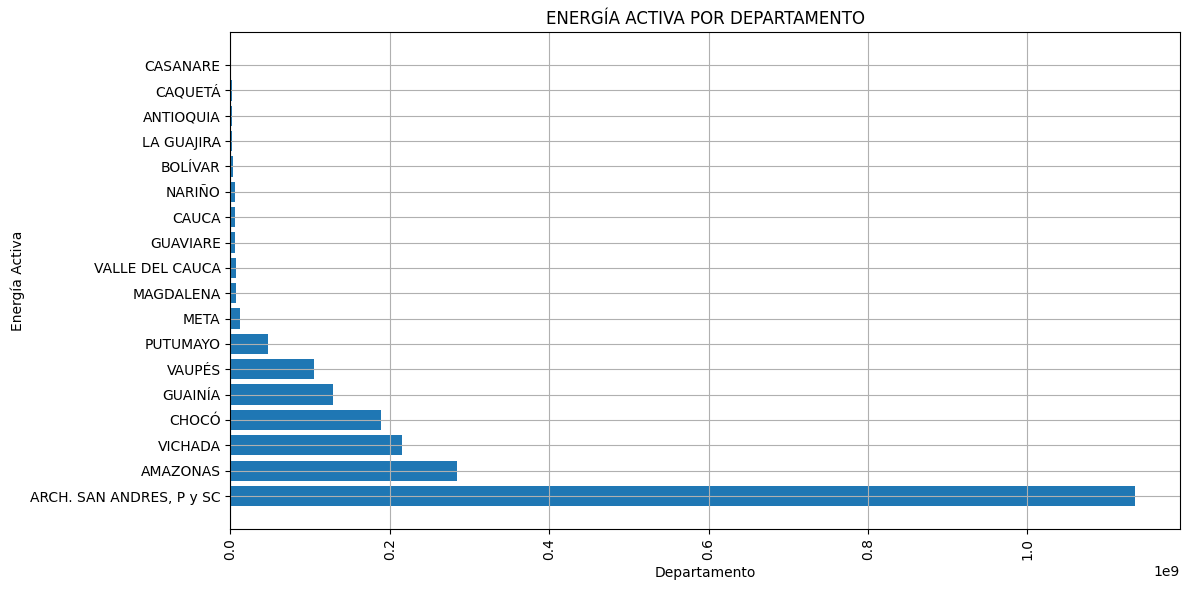

In [20]:
import matplotlib.pyplot as plt

df_departamento = df_departamento.sort_values(by= 'ENERGÍA ACTIVA', ascending=False)
plt.figure(figsize=(12,6))
plt.barh(
    df_departamento['DEPARTAMENTO'],
    df_departamento['ENERGÍA ACTIVA']
)

plt.title( 'ENERGÍA ACTIVA POR DEPARTAMENTO')
plt.xlabel('Departamento')
plt.ylabel('Energía Activa')
plt.xticks(rotation=90)
plt.grid()
plt.tight_layout()


plt.show()

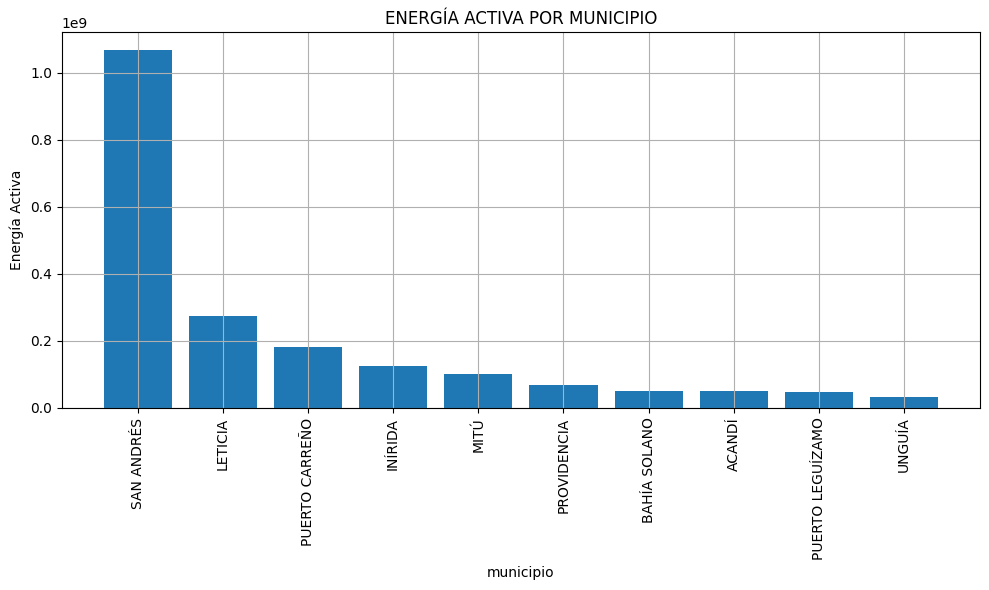

,DEPARTAMENTO,MUNICIPIO,ENERGÍA ACTIVA,ENERGÍA REACTIVA
5,"ARCH. SAN ANDRES, P y SC",SAN ANDRÉS,1067664571,277893847
0,AMAZONAS,LETICIA,275393747,76335604
47,VICHADA,PUERTO CARREÑO,180373573,54941541
27,GUAINÍA,INÍRIDA,125922933,37670368
43,VAUPÉS,MITÚ,100278877,26937412
4,"ARCH. SAN ANDRES, P y SC",PROVIDENCIA,67046651,15835341
15,CHOCÓ,BAHÍA SOLANO,49967781,16782708
13,CHOCÓ,ACANDÍ,49742602,16922871
40,PUTUMAYO,PUERTO LEGUÍZAMO,47571610,15242332
25,CHOCÓ,UNGUÍA,31317854,10456848


In [21]:
#visualización del TOP 10 de municipios con mayor energia activa
top_municipios = df_municipio.sort_values(
    by='ENERGÍA ACTIVA',
    ascending=False
).head(10)
plt.figure(figsize=(10,6))
plt.bar(
    top_municipios['MUNICIPIO'],
    top_municipios['ENERGÍA ACTIVA']
)

plt.title( 'ENERGÍA ACTIVA POR MUNICIPIO')
plt.xlabel('municipio')
plt.ylabel('Energía Activa')
plt.xticks(rotation=90)
plt.grid()
plt.tight_layout()


plt.show()



top_municipios



In [22]:
df_departamento

,DEPARTAMENTO,ENERGÍA ACTIVA,ENERGÍA REACTIVA
2,"ARCH. SAN ANDRES, P y SC",1134711222,293729188
0,AMAZONAS,284304581,79543800
17,VICHADA,215502520,69940306
7,CHOCÓ,188695165,66498206
8,GUAINÍA,129313950,38703332
16,VAUPÉS,104372341,28082757
14,PUTUMAYO,47571610,15242332
12,META,11993007,4364023
11,MAGDALENA,6546829,2385435
15,VALLE DEL CAUCA,6543719,2305185


In [23]:
df_anual

,AÑO SERVICIO,ENERGÍA ACTIVA,ENERGÍA REACTIVA
0,2020,276221185,89494014
1,2021,363422077,108901252
2,2022,391245163,115016813
3,2023,330208771,94014895
4,2024,324666043,87510298
5,2025,435623628,108084020
6,2026,35450899,8430342


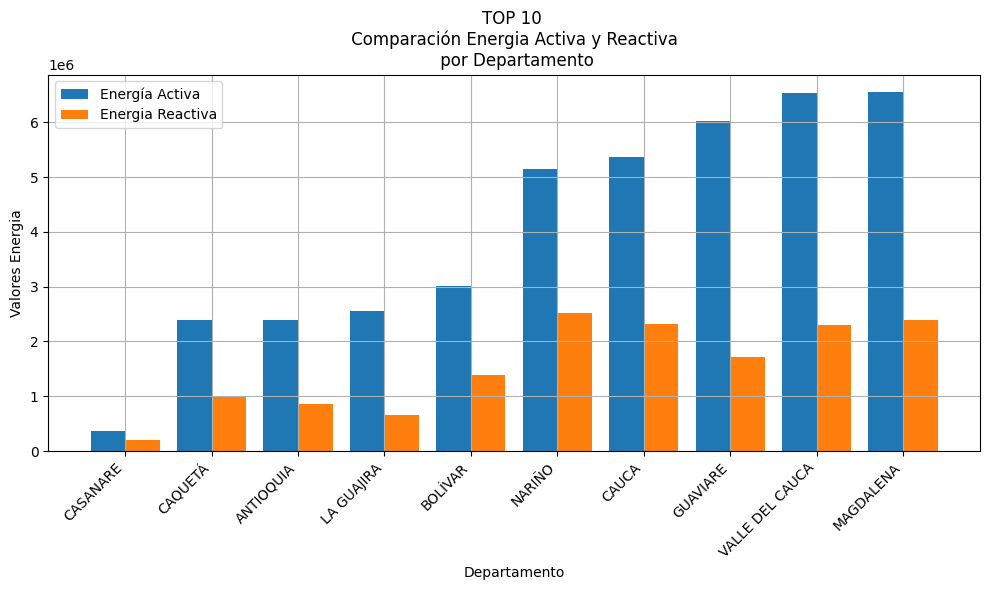

In [26]:
# Visualizacion - TOP 10 - Comparación entre Energía y Reactiva

top_departamentos = df_departamento.sort_values(by='ENERGÍA ACTIVA', ascending=True).head(10)

plt.figure(figsize=(10,6))

x= range(len(top_departamentos))
ancho = 0.4

plt.bar(
    [i - ancho / 2 for i in x],
    top_departamentos['ENERGÍA ACTIVA'],
    width= ancho,
    label='Energía Activa'
)

#for in x:
#res = i - ancho/2

plt.bar(
    [i + ancho / 2 for i in x],
    top_departamentos['ENERGÍA REACTIVA'],
    width = ancho,
    label = 'Energia Reactiva'
)

plt.title('TOP 10 \n Comparación Energia Activa y Reactiva \n por Departamento')
plt.xlabel('Departamento')
plt.ylabel('Valores Energia')
plt.xticks(x, top_departamentos['DEPARTAMENTO'],rotation=45, ha='right')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

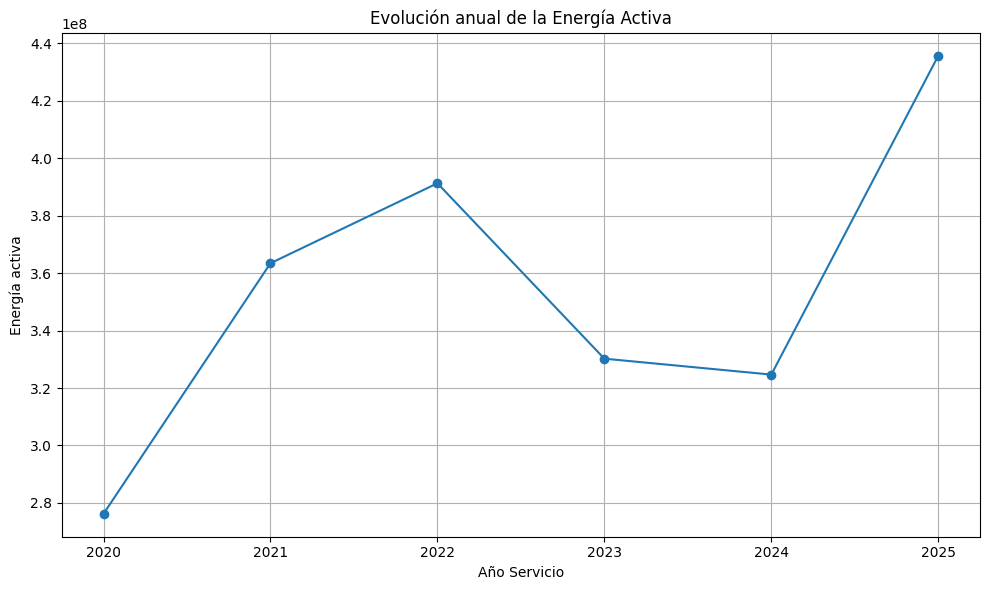

In [29]:
# Filtrar sin el año 2026
df_anual = df_anual[df_anual['AÑO SERVICIO']!=2026]
df_anual = df_anual.sort_values(by='AÑO SERVICIO')

plt.figure(figsize=(10,6))
plt.plot(
    df_anual['AÑO SERVICIO'],
    df_anual['ENERGÍA ACTIVA'],
    marker = 'o'
)

plt.title('Evolución anual de la Energía Activa')
plt.xlabel('Año Servicio')
plt.ylabel('Energía activa')
plt.grid()
plt.tight_layout()
plt.show()

/tmp/ipykernel_26855/1441600879.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


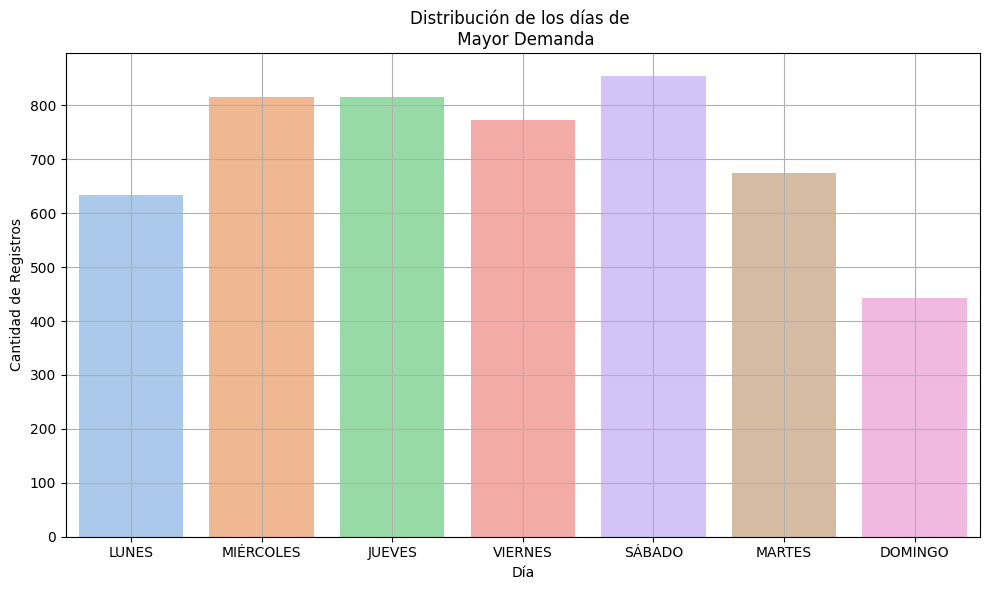

In [31]:
# Visualización de la Categoría DIA DE DEMANDA MÁXIMA
import seaborn as sns

plt.figure(figsize=(10,6))

sns.countplot(
     data=df_zni,
     x='DÍA DE DEMANDA MÁXIMA',
     palette='pastel'
)

plt.title('Distribución de los días de \n Mayor Demanda')
plt.xlabel('Día')
plt.ylabel('Cantidad de Registros')
plt.grid()
plt.tight_layout()
plt.show()